In [283]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [284]:
df = pd.read_csv("dataset.csv")
df.head()

,text,clean_text,style,tone
0,You are officially ordered to immediately and ...,you be officially order to immediately and ful...,academic,urgent
1,Your thesis methodology is a complete and utte...,your thesis methodology be a complete and utte...,academic,aggressive
2,I am officially rejecting your incredibly path...,i be officially reject your incredibly patheti...,academic,aggressive
3,The quarterly performance review will be condu...,the quarterly performance review will be condu...,business,neutral
4,What an absolutely spectacular and deeply insp...,what an absolutely spectacular and deeply insp...,academic,friendly


In [285]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        375 non-null    str  
 1   clean_text  375 non-null    str  
 2   style       375 non-null    str  
 3   tone        375 non-null    str  
dtypes: str(4)
memory usage: 11.8 KB


In [286]:
df.isnull().sum()

text          0
clean_text    0
style         0
tone          0
dtype: int64

style
academic    199
business    176
Name: count, dtype: int64


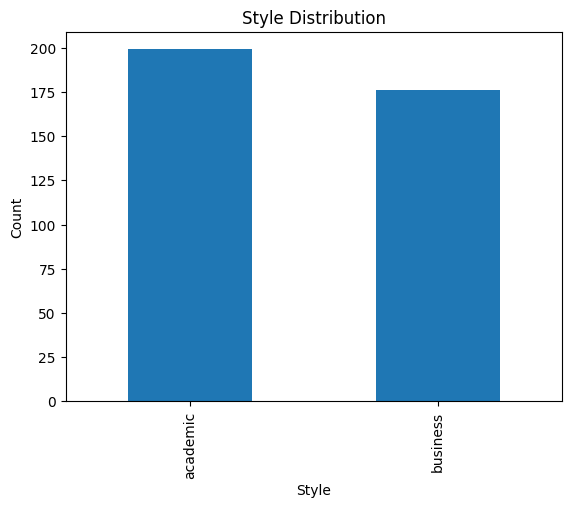

In [287]:
style_counts = df["style"].value_counts()

print(style_counts)

style_counts.plot(kind="bar")

plt.title("Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")

plt.show()

tone
aggressive    80
friendly      80
sarcastic     80
neutral       79
urgent        56
Name: count, dtype: int64


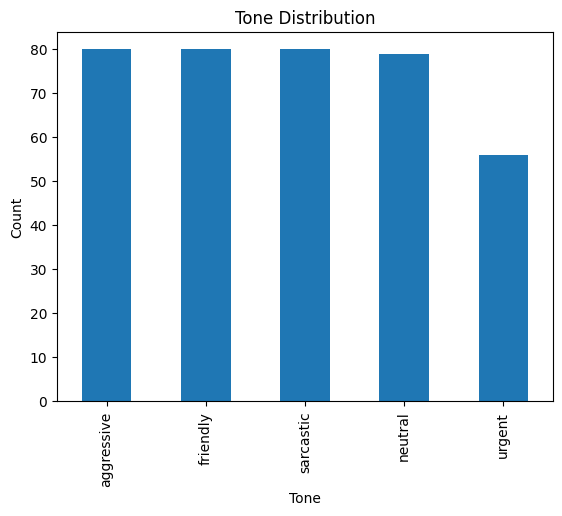

In [288]:
tone_counts = df["tone"].value_counts()

print(tone_counts)

tone_counts.plot(kind="bar")

plt.title("Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")

plt.show()

tone      aggressive  friendly  neutral  sarcastic  urgent
style                                                     
academic          40        40       40         40      39
business          40        40       39         40      17


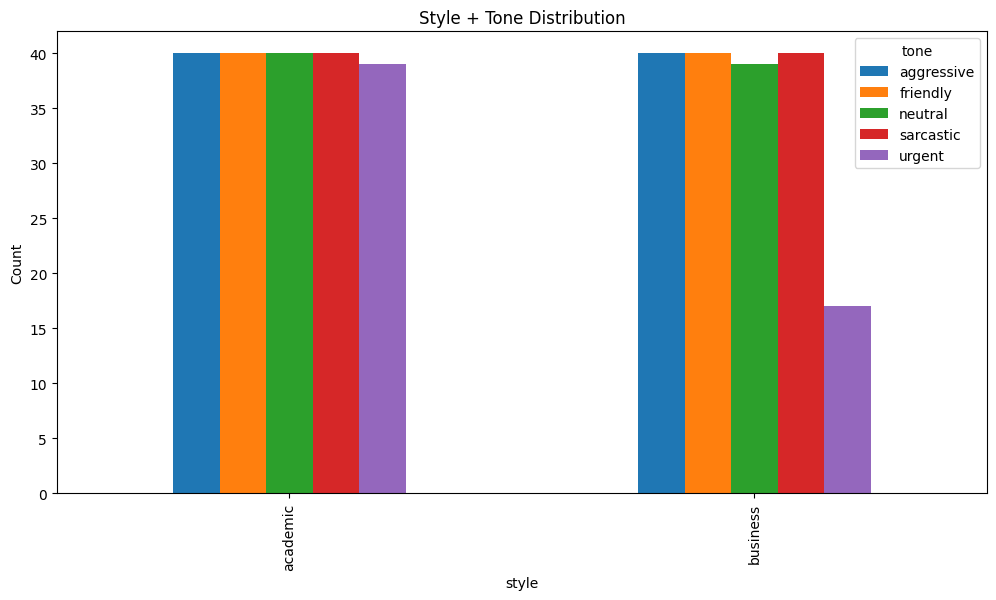

In [289]:
combo_counts = (
    df.groupby(["style", "tone"])
      .size()
      .unstack(fill_value=0)
)

print(combo_counts)

combo_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Style + Tone Distribution")
plt.ylabel("Count")

plt.show()

In [290]:
df["clean_text"] = df["text"].astype(str)
df["text_length"] = df["clean_text"].apply(len)

df["text_length"].describe()

count    375.000000
mean     394.909333
std      226.046082
min       10.000000
25%      218.500000
50%      404.000000
75%      569.000000
max      824.000000
Name: text_length, dtype: float64

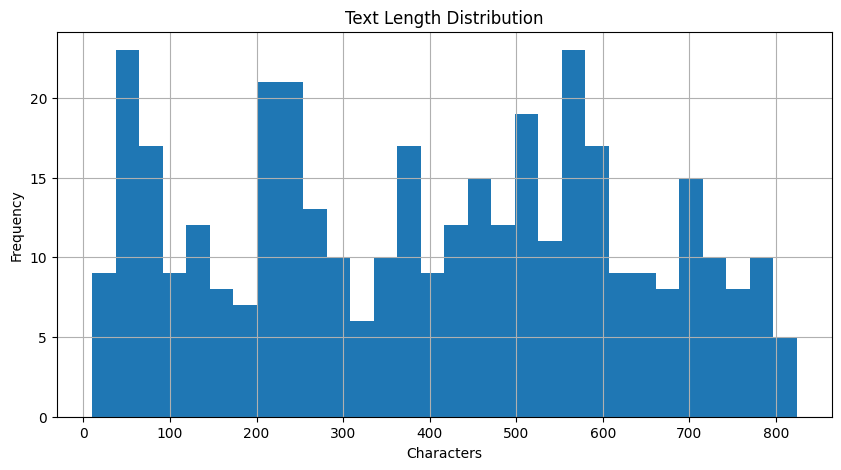

In [291]:
df["text_length"].hist(
    bins=30,
    figsize=(10, 5)
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

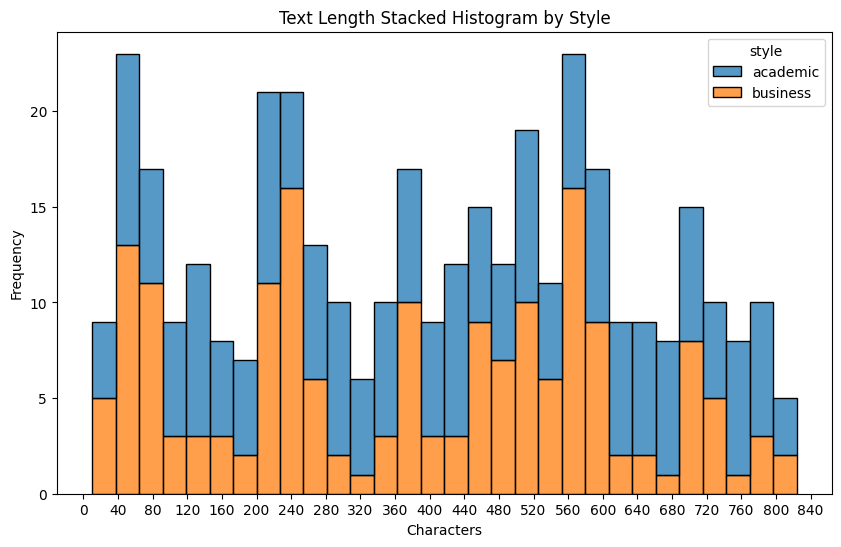

In [294]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="style",
    multiple="stack",
    bins=30
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(40))

plt.title("Text Length Stacked Histogram by Style")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

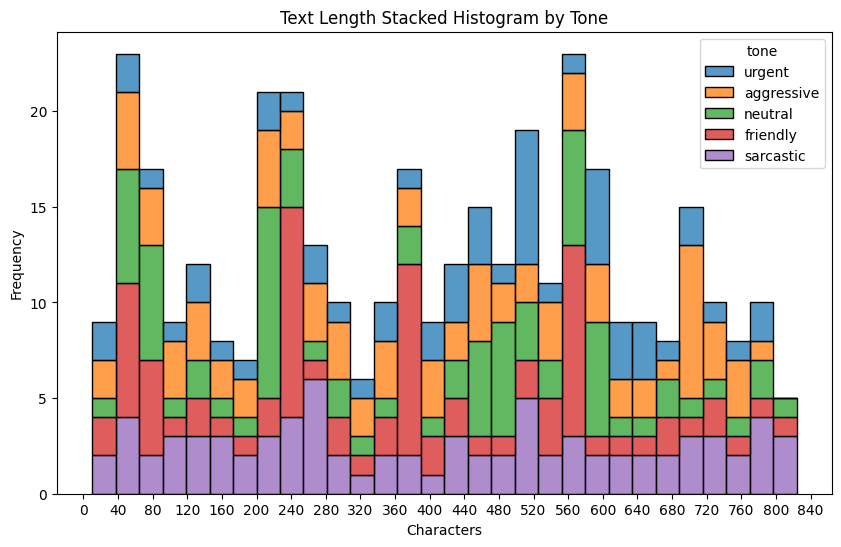

In [293]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="tone",
    multiple="stack",
    bins=30
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(40))
plt.title("Text Length Stacked Histogram by Tone")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()